In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('Telco-Customer-Churn.csv')

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [20]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [22]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

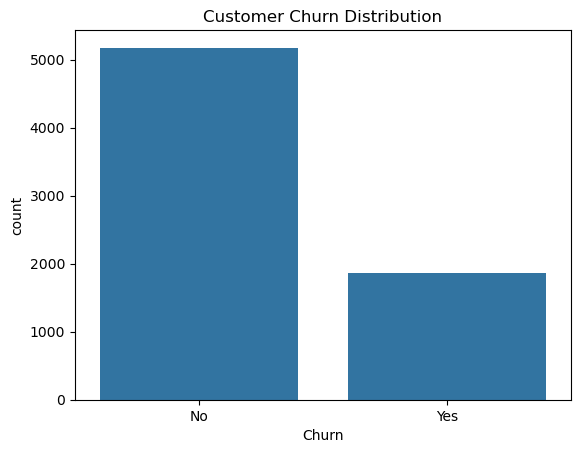

In [24]:
sns.countplot(data=df,x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

In [26]:
df['TotalCharges'].dtype

<StringDtype(na_value=nan)>

In [28]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [29]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [36]:
df=df.dropna(subset=['TotalCharges'])

# Distributions for seeing the frequency

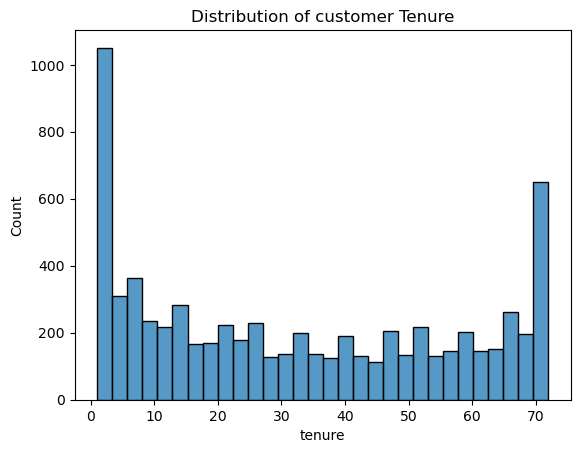

In [37]:
#Tenure
sns.histplot(data=df,x="tenure",bins=30)
plt.title('Distribution of customer Tenure')
plt.show()

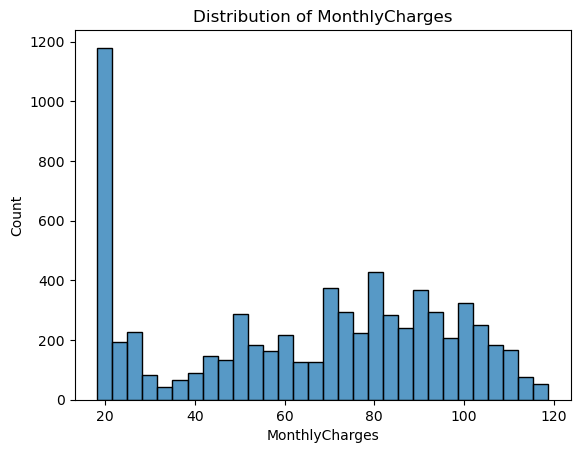

In [38]:
sns.histplot(data=df,x='MonthlyCharges',bins=30)
plt.title('Distribution of MonthlyCharges')
plt.show()

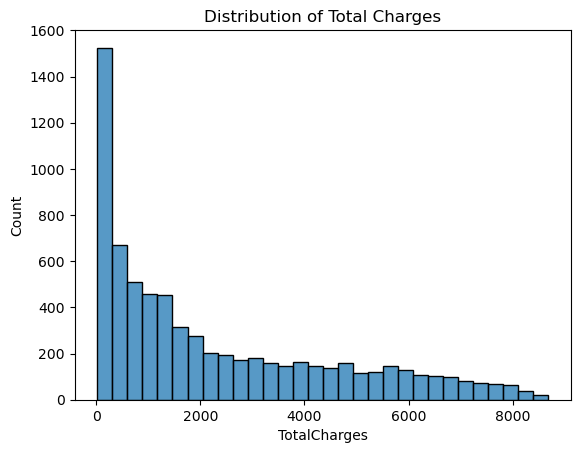

In [40]:
sns.histplot(data=df,x='TotalCharges',bins=30)
plt.title('Distribution of Total Charges')
plt.show()

# BoxPlot for outliers

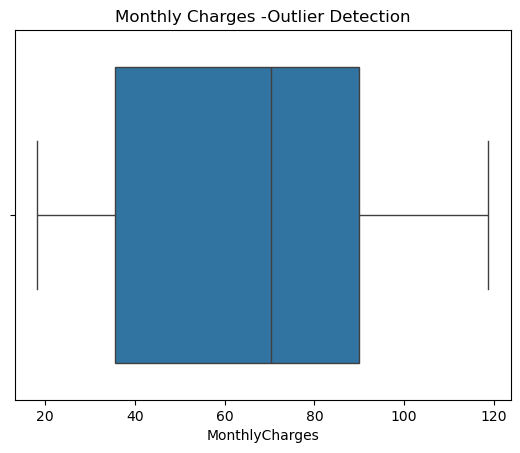

In [41]:
sns.boxplot(data=df,x='MonthlyCharges')
plt.title('Monthly Charges -Outlier Detection')
plt.show()

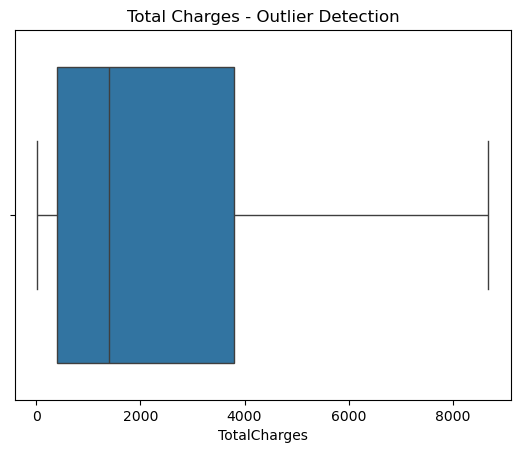

In [42]:
sns.boxplot(data=df, x="TotalCharges")
plt.title("Total Charges - Outlier Detection")
plt.show()

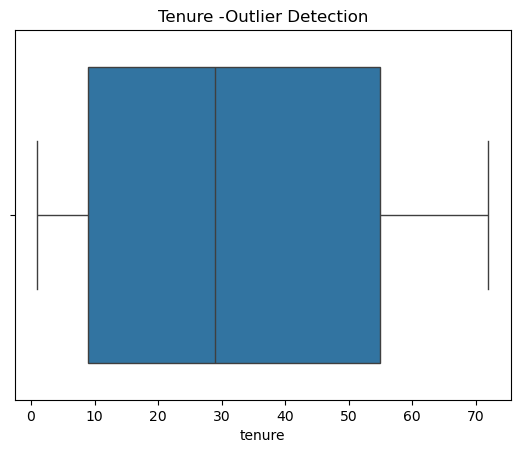

In [43]:
sns.boxplot(data=df,x='tenure')
plt.title('Tenure -Outlier Detection')
plt.show()

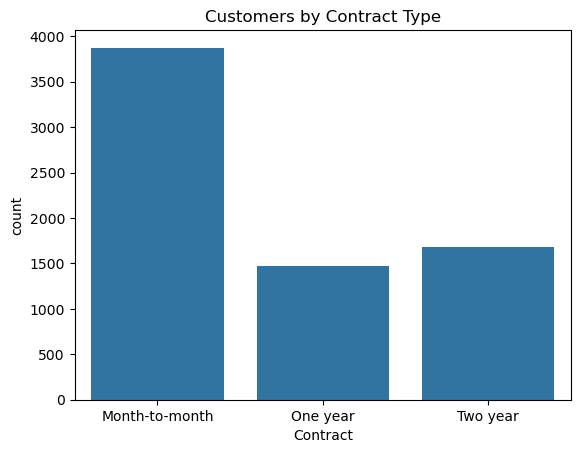

In [45]:
#Categorical Analysis
sns.countplot(data=df, x="Contract")
plt.title("Customers by Contract Type")
plt.xticks(rotation=0)
plt.show()

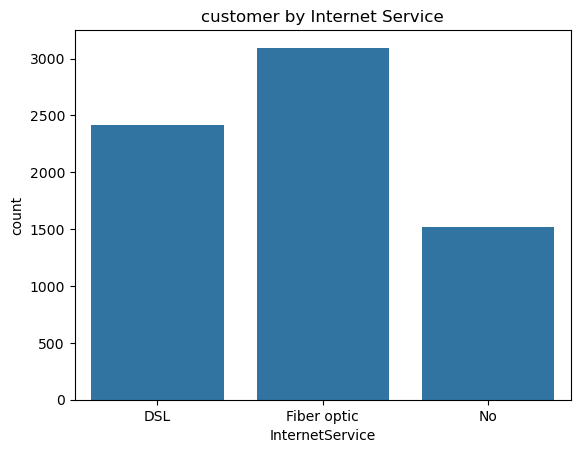

In [49]:
sns.countplot(data=df,x='InternetService')
plt.title('customer by Internet Service')
plt.xticks(rotation=0)
plt.show()

In [55]:
#pd.crosstab() creates a relationship table between two categorical columns.

churn_contract=pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100

print(churn_contract)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


Text(0.5, 1.0, 'churn by contract Type')

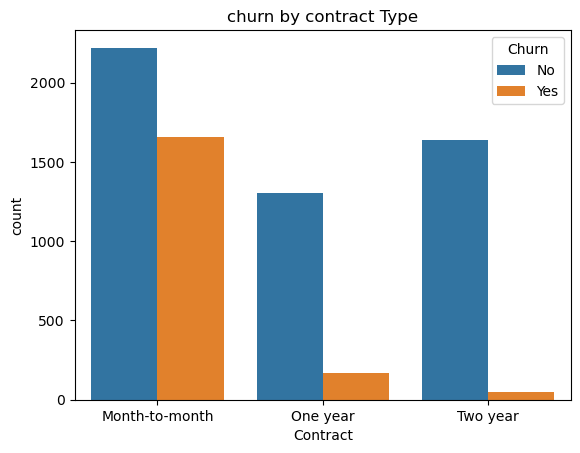

In [56]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)
plt.title("churn by contract Type")